In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
DATA_DIR = '/content/drive/MyDrive/dataset/mrnet_all'
BATCH_SIZE = 1
NUM_EPOCHS = 35
RANDOM_SEED = 42
MAX_SLICES = 40          # Single view at a time, same as V11
LR = 1e-4
WEIGHT_DECAY = 0.02
PATIENCE = 10
DROPOUT = 0.3

# Loss weights for each task
TASK_WEIGHT_ACL = 1.0
TASK_WEIGHT_MENISCUS = 1.0
TASK_WEIGHT_ABNORMAL = 0.5

# Model selection weights (for composite AUC)
SEL_WEIGHT_ACL = 0.5
SEL_WEIGHT_MEN = 0.3
SEL_WEIGHT_ABN = 0.2

# Which views to train (set to subset for testing)
VIEWS = ['sagittal', 'coronal', 'axial']
ATTN_HIDDEN = 128    # Slice attention hidden dimension



In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')


Device: cuda
  GPU: Tesla T4


In [5]:
data_path = Path(DATA_DIR)
metadata = pd.read_csv(data_path / 'metadata.csv')

print(f"Total patients: {len(metadata)}")
print(f"\nLabel distribution:")
print(f"  ACL tear:      {metadata.label_acl.sum():4d} / {len(metadata)} ({100*metadata.label_acl.mean():.1f}%)")
print(f"  Meniscus tear: {metadata.label_meniscus.sum():4d} / {len(metadata)} ({100*metadata.label_meniscus.mean():.1f}%)")
print(f"  Abnormal:      {metadata.label_abnormal.sum():4d} / {len(metadata)} ({100*metadata.label_abnormal.mean():.1f}%)")

# Stratified split on ACL label (primary task)
train_df, val_df = train_test_split(
    metadata, test_size=0.15, random_state=RANDOM_SEED,
    stratify=metadata['label_acl']
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"\nTrain: {len(train_df)} patients")
print(f"  ACL: {train_df.label_acl.sum()} tear / {(train_df.label_acl==0).sum()} normal")
print(f"Val: {len(val_df)} patients")
print(f"  ACL: {val_df.label_acl.sum()} tear / {(val_df.label_acl==0).sum()} normal")


Total patients: 1250

Label distribution:
  ACL tear:       262 / 1250 (21.0%)
  Meniscus tear:  449 / 1250 (35.9%)
  Abnormal:      1008 / 1250 (80.6%)

Train: 1062 patients
  ACL: 223 tear / 839 normal
Val: 188 patients
  ACL: 39 tear / 149 normal


In [6]:
class SingleViewDataset(Dataset):
    """Loads ONE view at a time from mrnet_all .npz files with 3 labels.
    This is the MRNet-faithful approach: one model per view.
    """
    def __init__(self, df, data_dir, view='sagittal', max_slices=MAX_SLICES, augment=False):
        self.df = df.reset_index(drop=True)
        self.data_dir = Path(data_dir)
        self.view = view
        self.max_slices = max_slices
        self.augment = augment
        self.valid_indices = []
        for idx in range(len(self.df)):
            fpath = self.data_dir / self.df.iloc[idx]['filename']
            if fpath.exists():
                self.valid_indices.append(idx)
        print(f"  [{view}] {len(self.valid_indices)} valid patients (of {len(self.df)})")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        patient_idx = self.valid_indices[idx]
        row = self.df.iloc[patient_idx]
        data = np.load(self.data_dir / row['filename'])
        volume = data[self.view]  # (S, 256, 256), uint8
        slices = volume.astype(np.float32) / 255.0

        # Center crop if too many slices
        if slices.shape[0] > self.max_slices:
            offset = (slices.shape[0] - self.max_slices) // 2
            slices = slices[offset:offset + self.max_slices]

        # 1. Stronger augmentation (add to SingleViewDataset.__getitem__)
        if self.augment:
            # Random horizontal flip
            if np.random.random() > 0.5:
                slices = slices[:, :, ::-1].copy()
            # Random slice dropout: zero out 10% of slices
            if np.random.random() > 0.5:
                n_drop = max(1, int(slices.shape[0] * 0.1))
                drop_idx = np.random.choice(slices.shape[0], n_drop, replace=False)
                slices[drop_idx] = 0.0
            # Random Gaussian noise
            if np.random.random() > 0.5:
                slices = slices + np.random.normal(0, 0.02, slices.shape).astype(np.float32)
                slices = np.clip(slices, 0, 1)

        # Grayscale -> 3-channel: (S, H, W) -> (S, 3, H, W)
        slices_3ch = np.stack((slices,)*3, axis=1)
        tensor = torch.FloatTensor(slices_3ch)

        labels = torch.LongTensor([
            int(row['label_acl']),
            int(row['label_meniscus']),
            int(row['label_abnormal'])
        ])
        return tensor, labels

    def get_label_counts(self):
        acl = [int(self.df.iloc[i]['label_acl']) for i in self.valid_indices]
        men = [int(self.df.iloc[i]['label_meniscus']) for i in self.valid_indices]
        abn = [int(self.df.iloc[i]['label_abnormal']) for i in self.valid_indices]
        return {'acl': acl, 'meniscus': men, 'abnormal': abn}


In [7]:
_tmp = SingleViewDataset(train_df, DATA_DIR, view='sagittal')
label_counts = _tmp.get_label_counts()

def compute_weight(labels):
    n = len(labels)
    n_pos = sum(labels)
    n_neg = n - n_pos
    w_neg = n / (2 * n_neg) if n_neg > 0 else 1.0
    w_pos = n / (2 * n_pos) if n_pos > 0 else 1.0
    return torch.FloatTensor([w_neg, w_pos]).to(device)

weight_acl = compute_weight(label_counts['acl'])
weight_meniscus = compute_weight(label_counts['meniscus'])
weight_abnormal = compute_weight(label_counts['abnormal'])

print(f"Class weights:")
print(f"  ACL:      Normal={weight_acl[0]:.3f}, Tear={weight_acl[1]:.3f}")
print(f"  Meniscus: Normal={weight_meniscus[0]:.3f}, Tear={weight_meniscus[1]:.3f}")
print(f"  Abnormal: Normal={weight_abnormal[0]:.3f}, Abnormal={weight_abnormal[1]:.3f}")


  [sagittal] 1062 valid patients (of 1062)
Class weights:
  ACL:      Normal=0.633, Tear=2.381
  Meniscus: Normal=0.774, Tear=1.412
  Abnormal: Normal=2.541, Abnormal=0.623


In [8]:
class MRNetV17SliceAttn(nn.Module):
    """Multi-task MRNet with Per-Task Gated Slice Attention."""
    def __init__(self, dropout=DROPOUT, attn_hidden=128):
        super().__init__()
        backbone = models.efficientnet_b0(weights='IMAGENET1K_V1')
        self.features = backbone.features
        self.pool = backbone.avgpool
        self.drop = nn.Dropout(p=dropout)

        # Shared slice attention with dropout
        self.slice_attn = nn.Sequential(
            nn.Linear(1280, attn_hidden),
            nn.Tanh(),
            nn.Dropout(p=0.4),
            nn.Linear(attn_hidden, 1)
        )

        # Per-task gates: sigmoid(-2) ≈ 0.12 → starts 88% max-pool
        self.gate_acl = nn.Parameter(torch.tensor(-2.0))
        self.gate_men = nn.Parameter(torch.tensor(-2.0))
        self.gate_abn = nn.Parameter(torch.tensor(-2.0))

        # Task heads
        self.head_acl = nn.Linear(1280, 2)
        self.head_meniscus = nn.Linear(1280, 2)
        self.head_abnormal = nn.Linear(1280, 2)

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        print(f"  Backbone: EfficientNet-B0 (all trainable)")
        print(f"  Pooling: Per-Task Gated Slice Attention (hidden={attn_hidden})")
        print(f"  Heads: ACL(1280->2), Men(1280->2), Abn(1280->2)")
        print(f"  Params: {trainable:,} trainable / {total:,} total")

    def forward(self, x):
        x = x.squeeze(0)
        features = self.features(x)
        pooled = self.pool(features).flatten(1)

        # Shared attention scores
        attn_scores = self.slice_attn(pooled)
        attn_weights = torch.softmax(attn_scores, dim=0)
        attn_feat = (attn_weights * pooled).sum(dim=0, keepdim=True)
        max_feat = torch.max(pooled, 0, keepdim=True)[0]

        # Per-task gating
        a_acl = torch.sigmoid(self.gate_acl)
        a_men = torch.sigmoid(self.gate_men)
        a_abn = torch.sigmoid(self.gate_abn)

        feat_acl = self.drop(a_acl * attn_feat + (1 - a_acl) * max_feat)
        feat_men = self.drop(a_men * attn_feat + (1 - a_men) * max_feat)
        feat_abn = self.drop(a_abn * attn_feat + (1 - a_abn) * max_feat)

        return (self.head_acl(feat_acl),
                self.head_meniscus(feat_men),
                self.head_abnormal(feat_abn))


In [9]:
def train_epoch(model, loader, optimizer, crits, device):
    model.train()
    total_loss = 0
    all_labels = {'acl': [], 'meniscus': [], 'abnormal': []}
    all_probs = {'acl': [], 'meniscus': [], 'abnormal': []}

    for volumes, labels in tqdm(loader, desc='Training', leave=False):
        volumes = volumes.to(device)
        lab_acl = labels[:, 0].to(device)
        lab_men = labels[:, 1].to(device)
        lab_abn = labels[:, 2].to(device)

        optimizer.zero_grad()
        out_acl, out_men, out_abn = model(volumes.float())

        loss = (TASK_WEIGHT_ACL * crits[0](out_acl, lab_acl) +
                TASK_WEIGHT_MENISCUS * crits[1](out_men, lab_men) +
                TASK_WEIGHT_ABNORMAL * crits[2](out_abn, lab_abn))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

        all_labels['acl'].extend(lab_acl.cpu().numpy())
        all_labels['meniscus'].extend(lab_men.cpu().numpy())
        all_labels['abnormal'].extend(lab_abn.cpu().numpy())
        all_probs['acl'].extend(torch.softmax(out_acl, 1)[:, 1].detach().cpu().numpy())
        all_probs['meniscus'].extend(torch.softmax(out_men, 1)[:, 1].detach().cpu().numpy())
        all_probs['abnormal'].extend(torch.softmax(out_abn, 1)[:, 1].detach().cpu().numpy())

    avg_loss = total_loss / len(loader)
    aucs = {}
    for task in ['acl', 'meniscus', 'abnormal']:
        try:
            aucs[task] = roc_auc_score(all_labels[task], all_probs[task])
        except ValueError:
            aucs[task] = 0.5
    return avg_loss, aucs


def validate(model, loader, crits, device):
    model.eval()
    total_loss = 0
    all_labels = {'acl': [], 'meniscus': [], 'abnormal': []}
    all_probs = {'acl': [], 'meniscus': [], 'abnormal': []}

    with torch.no_grad():
        for volumes, labels in tqdm(loader, desc='Validating', leave=False):
            volumes = volumes.to(device)
            lab_acl = labels[:, 0].to(device)
            lab_men = labels[:, 1].to(device)
            lab_abn = labels[:, 2].to(device)

            out_acl, out_men, out_abn = model(volumes.float())
            loss = (TASK_WEIGHT_ACL * crits[0](out_acl, lab_acl) +
                    TASK_WEIGHT_MENISCUS * crits[1](out_men, lab_men) +
                    TASK_WEIGHT_ABNORMAL * crits[2](out_abn, lab_abn))
            total_loss += loss.item()

            all_labels['acl'].extend(lab_acl.cpu().numpy())
            all_labels['meniscus'].extend(lab_men.cpu().numpy())
            all_labels['abnormal'].extend(lab_abn.cpu().numpy())
            all_probs['acl'].extend(torch.softmax(out_acl, 1)[:, 1].cpu().numpy())
            all_probs['meniscus'].extend(torch.softmax(out_men, 1)[:, 1].cpu().numpy())
            all_probs['abnormal'].extend(torch.softmax(out_abn, 1)[:, 1].cpu().numpy())

    avg_loss = total_loss / len(loader)
    aucs = {}
    for task in ['acl', 'meniscus', 'abnormal']:
        try:
            aucs[task] = roc_auc_score(all_labels[task], all_probs[task])
        except ValueError:
            aucs[task] = 0.5
    return avg_loss, aucs, all_labels, all_probs


In [ ]:
view_results = {}  # Store per-view val predictions

for view in VIEWS:
    print(f"\n{'='*60}")
    print(f"  TRAINING VIEW: {view.upper()}")
    print(f"{'='*60}")

    # Create datasets for this view
    print("Creating datasets...")
    train_dataset = SingleViewDataset(train_df, DATA_DIR, view=view, augment=True)
    val_dataset = SingleViewDataset(val_df, DATA_DIR, view=view, augment=False)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=2, pin_memory=True)

    # Create model, optimizer, scheduler
    print("Creating model...")
    model = MRNetV17SliceAttn(dropout=DROPOUT, attn_hidden=ATTN_HIDDEN).to(device)
    crits = [
        nn.CrossEntropyLoss(weight=weight_acl),
        nn.CrossEntropyLoss(weight=weight_meniscus),
        nn.CrossEntropyLoss(weight=weight_abnormal),
    ]
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.3, patience=5, min_lr=1e-7)

    # Training loop
    best_composite = 0.0
    no_improve = 0
    save_path = f'/content/drive/MyDrive/dataset/best_v17_{view}.pth'

    for epoch in range(NUM_EPOCHS):
        lr = optimizer.param_groups[0]['lr']
        train_loss, train_aucs = train_epoch(model, train_loader, optimizer, crits, device)
        val_loss, val_aucs, val_labels, val_probs = validate(model, val_loader, crits, device)

        composite_val = (SEL_WEIGHT_ACL * val_aucs['acl'] +
                         SEL_WEIGHT_MEN * val_aucs['meniscus'] +
                         SEL_WEIGHT_ABN * val_aucs['abnormal'])
        scheduler.step(composite_val)

        gap = 100 * ((SEL_WEIGHT_ACL * train_aucs['acl'] + SEL_WEIGHT_MEN * train_aucs['meniscus'] +
                       SEL_WEIGHT_ABN * train_aucs['abnormal']) - composite_val)

        print(f"[{view}] Epoch {epoch+1}/{NUM_EPOCHS}  (lr={lr:.1e})")
        print(f"  Train: loss={train_loss:.4f}  ACL={train_aucs['acl']:.4f}  Men={train_aucs['meniscus']:.4f}  Abn={train_aucs['abnormal']:.4f}")
        print(f"  Val:   loss={val_loss:.4f}  ACL={val_aucs['acl']:.4f}  Men={val_aucs['meniscus']:.4f}  Abn={val_aucs['abnormal']:.4f}  (gap={gap:.1f}%)")

        a_acl = torch.sigmoid(model.gate_acl).item()
        a_men = torch.sigmoid(model.gate_men).item()
        a_abn = torch.sigmoid(model.gate_abn).item()
        print(f"  Alpha — ACL:{a_acl:.3f}  Men:{a_men:.3f}  Abn:{a_abn:.3f}")
        if composite_val > best_composite:
            best_composite = composite_val
            no_improve = 0
            torch.save(model.state_dict(), save_path)
            print(f"  -> Saved best {view} (Comp={best_composite:.4f})")
        else:
            no_improve += 1
            print(f"  -> No improvement ({no_improve}/{PATIENCE})")
            if no_improve >= PATIENCE:
                print(f"  Early stopping {view} at epoch {epoch+1}")
                break

    # Load best and collect val predictions
    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    _, _, val_labels, val_probs = validate(model, val_loader, crits, device)
    view_results[view] = {'labels': val_labels, 'probs': val_probs, 'aucs': {
        t: roc_auc_score(val_labels[t], val_probs[t]) for t in ['acl', 'meniscus', 'abnormal']
    }}
    print(f"\n  Best {view}: ACL={view_results[view]['aucs']['acl']:.4f}, "
          f"Men={view_results[view]['aucs']['meniscus']:.4f}, "
          f"Abn={view_results[view]['aucs']['abnormal']:.4f}")

    del model, optimizer, scheduler
    torch.cuda.empty_cache()


  TRAINING VIEW: SAGITTAL
Creating datasets...
  [sagittal] 1062 valid patients (of 1062)
  [sagittal] 188 valid patients (of 188)
Creating model...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 142MB/s]


  Backbone: EfficientNet-B0 (all trainable)
  Pooling: Per-Task Gated Slice Attention (hidden=128)
  Heads: ACL(1280->2), Men(1280->2), Abn(1280->2)
  Params: 4,179,334 trainable / 4,179,334 total


Training:   0%|          | 0/1062 [00:00<?, ?it/s]

In [ ]:
# Cell 9B: Resume — Load saved view models and rebuild view_results
print("Loading pre-trained view models from Drive...\n")
view_results = {}
ALL_VIEWS = ['sagittal', 'coronal', 'axial']

crits = [
    nn.CrossEntropyLoss(weight=weight_acl),
    nn.CrossEntropyLoss(weight=weight_meniscus),
    nn.CrossEntropyLoss(weight=weight_abnormal),
]

for view in ALL_VIEWS:
    save_path = f'/content/drive/MyDrive/dataset/best_v17_{view}.pth'
    print(f"--- {view.upper()} ---")

    val_dataset = SingleViewDataset(val_df, DATA_DIR, view=view, augment=False)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=2, pin_memory=True)

    model = MRNetV17SliceAttn(dropout=DROPOUT, attn_hidden=ATTN_HIDDEN)
    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))

    _, _, val_labels, val_probs = validate(model, val_loader, crits, device)

    view_results[view] = {
        'labels': val_labels,
        'probs': val_probs,
        'aucs': {t: roc_auc_score(val_labels[t], val_probs[t])
                 for t in ['acl', 'meniscus', 'abnormal']}
    }
    a = view_results[view]['aucs']
    print(f"  ACL={a['acl']:.4f}  Men={a['meniscus']:.4f}  Abn={a['abnormal']:.4f}\n")
    del model
    torch.cuda.empty_cache()

print("✓ Ready — run Cell 10 next.")


Loading pre-trained view models from Drive...

--- SAGITTAL ---
  [sagittal] 188 valid patients (of 188)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 108MB/s] 


  Backbone: EfficientNet-B0 (all trainable)
  Heads: ACL(1280->2), Men(1280->2), Abn(1280->2)
  Params: 4,015,234 trainable / 4,015,234 total


Validating:   0%|          | 0/188 [00:00<?, ?it/s]

In [ ]:
ALL_VIEWS = ['sagittal', 'coronal', 'axial']

print("\n" + "="*60)
print("  COMBINING VIEWS (MRNet-style)")
print("="*60)

# Per-view AUC summary
for view in ALL_VIEWS:
    a = view_results[view]['aucs']
    print(f"  {view:10s}: ACL={a['acl']:.4f}  Men={a['meniscus']:.4f}  Abn={a['abnormal']:.4f}")

# Simple average combination (no extra training needed)
print("\n--- Method 1: Simple Average ---")
combined_probs = {}
for task in ['acl', 'meniscus', 'abnormal']:
    combined_probs[task] = np.mean(
        [view_results[v]['probs'][task] for v in ALL_VIEWS], axis=0
    )
    labels = view_results[ALL_VIEWS[0]]['labels'][task]
    auc = roc_auc_score(labels, combined_probs[task])
    print(f"  {task:10s} AUC = {auc:.4f}")

composite = (SEL_WEIGHT_ACL * roc_auc_score(labels, combined_probs['acl']) +
             SEL_WEIGHT_MEN * roc_auc_score(view_results[ALL_VIEWS[0]]['labels']['meniscus'], combined_probs['meniscus']) +
             SEL_WEIGHT_ABN * roc_auc_score(view_results[ALL_VIEWS[0]]['labels']['abnormal'], combined_probs['abnormal']))
print(f"  Composite = {composite:.4f}")

# Learned combination via logistic regression (MRNet paper approach)
print("\n--- Method 2: Logistic Regression (MRNet paper) ---")
for task in ['acl', 'meniscus', 'abnormal']:
    X = np.column_stack([view_results[v]['probs'][task] for v in ALL_VIEWS])
    y = np.array(view_results[ALL_VIEWS[0]]['labels'][task])
    lr_model = LogisticRegression(random_state=RANDOM_SEED)
    lr_model.fit(X, y)
    lr_probs = lr_model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, lr_probs)
    print(f"  {task:10s} AUC = {auc:.4f}  (weights: {', '.join(f'{v}={w:.3f}' for v, w in zip(ALL_VIEWS, lr_model.coef_[0]))})")



  COMBINING VIEWS (MRNet-style)


KeyError: 'sagittal'

IndexError: list index out of range

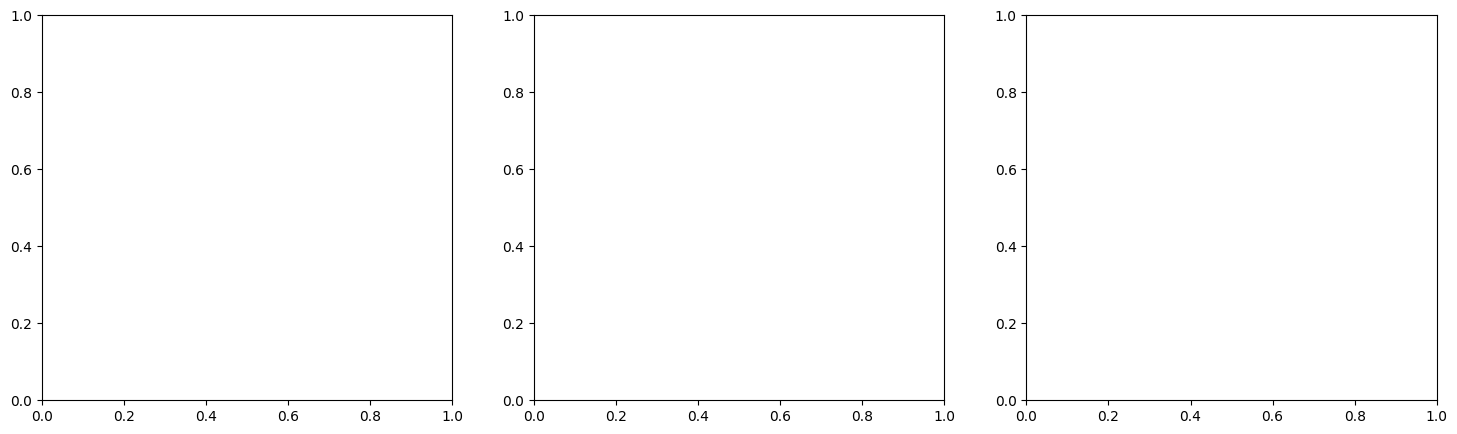

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, task, title in zip(axes, ['acl', 'meniscus', 'abnormal'],
                            ['ACL Tear', 'Meniscus Tear', 'Abnormality']):
    labels = view_results[VIEWS[0]]['labels'][task]
    probs = combined_probs[task]
    preds = [1 if p >= 0.5 else 0 for p in probs]
    cm = confusion_matrix(labels, preds)
    auc = roc_auc_score(labels, probs)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Positive'], yticklabels=['Normal', 'Positive'], ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{title} (AUC={auc:.3f})')

plt.suptitle('V17 MRNet Per-View Multi-Task — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dataset/confusion_matrix_v17.png', dpi=150)
plt.show()